In [3]:
import urllib3
import ssl
import matplotlib.pyplot as plt

from modules import importar_datos, cargar_datos, metricas_volatilidad

# Configuración de seguridad (si no no permite acceder a la API)

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
ssl._create_default_https_context = ssl._create_unverified_context

# Configuración de la base de datos

DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "postgres",
    "user": "postgres",
    "password": "IK008626"
}

data = cargar_datos(DB_CONFIG)

print(data.head())

df= data.copy()

        fecha     aud     cad     chf      cyp     czk     dkk      eek  \
0  2000-01-24  1.5264  1.4364  1.6121  0.57655  35.806  7.4437  15.6466   
1  2000-01-31  1.5386  1.4128  1.6086  0.57617  35.800  7.4429  15.6466   
2  2000-02-07  1.5526  1.4245  1.6069  0.57588  35.669  7.4439  15.6466   
3  2000-02-14  1.5607  1.4309  1.6047  0.57601  35.699  7.4457  15.6466   
4  2000-02-21  1.5964  1.4480  1.6078  0.57632  35.650  7.4473  15.6466   

       gbp     hkd  ...     nzd     pln      rol     sek     sgd     sit  \
0  0.60758  7.7621  ...  1.9723  4.1216  18369.0  8.5341  1.6866  200.11   
1  0.60798  7.5967  ...  1.9843  4.1061  18062.0  8.5320  1.6560  200.59   
2  0.61494  7.6669  ...  1.9955  4.0934  18359.0  8.4712  1.6685  200.94   
3  0.61582  7.6617  ...  2.0086  4.0653  18443.0  8.5281  1.6741  201.13   
4  0.61964  7.7301  ...  2.0351  4.0727  18703.0  8.5667  1.6994  201.76   

      skk       trl      usd     zar  
0  42.349  550911.0  0.99756  6.1644  
1  42.303  546

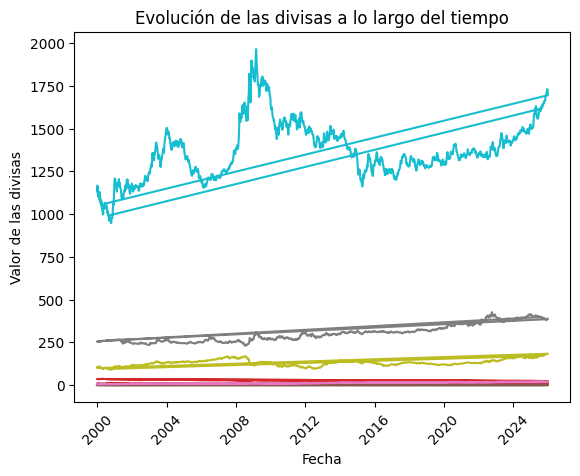

In [4]:
x = df["fecha"]
y = df.drop(columns=["fecha"])

y_filtered = y.loc[:, (y <= 400000).all()]

plt.plot(x, y_filtered)
plt.xlabel("Fecha")
plt.ylabel("Valor de las divisas")
plt.title("Evolución de las divisas a lo largo del tiempo")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Desviación estandar de cada divisa
desviaciones_estandar = y.std()

desviaciones_estandar_normalizada = y.std() / y.mean()

print(desviaciones_estandar_normalizada.sort_values(ascending=False))

trl    3.562731e-01
zar    3.291102e-01
isk    3.005724e-01
rol    2.380884e-01
chf    1.817343e-01
huf    1.644698e-01
nok    1.450012e-01
jpy    1.406851e-01
sgd    1.321836e-01
usd    1.299261e-01
hkd    1.287713e-01
gbp    1.217779e-01
krw    1.195377e-01
czk    1.125347e-01
nzd    1.070366e-01
skk    1.041188e-01
aud    9.315781e-02
sek    8.821129e-02
lvl    8.356626e-02
pln    7.246574e-02
cad    6.360599e-02
sit    5.297475e-02
mtl    2.874762e-02
ltl    2.589601e-02
cyp    8.027648e-03
dkk    1.505514e-03
eek    2.272575e-16
dtype: float64


In [41]:
# Variación de valor respecto al euro

rendimiento_total = (y.iloc[0]-y.iloc[-1]) / y.iloc[-1]
print(rendimiento_total.sort_values(ascending=False))

chf    0.110860
mxn    0.096197
pln    0.087869
czk    0.024734
thb    0.016330
sgd    0.011385
isk    0.001357
bgn    0.000000
dkk   -0.004365
myr   -0.010361
brl   -0.028408
ron   -0.028865
hkd   -0.034412
gbp   -0.036520
usd   -0.036741
huf   -0.044045
sek   -0.052521
ils   -0.062527
zar   -0.075269
cad   -0.105969
aud   -0.111219
cny   -0.125849
nok   -0.155781
php   -0.165648
idr   -0.182534
nzd   -0.184024
inr   -0.202745
krw   -0.205760
jpy   -0.290835
try   -0.698281
hrk         NaN
rub         NaN
dtype: float64
